Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
C:\Users\ankit\AppData\Roaming\Python\Python314\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'FitnessMax' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
C:\Users\ankit\AppData\Roaming\Python\Python314\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


gen	nevals
0  	20    
1  	4     
2  	4     
3  	5     
4  	4     
5  	2     
6  	2     
7  	6     
8  	3     
9  	5     
10 	3     
11 	5     
12 	4     
13 	4     
14 	2     
15 	6     

Best K Found:
2

Best Silhouette Score:
0.16823269494218376


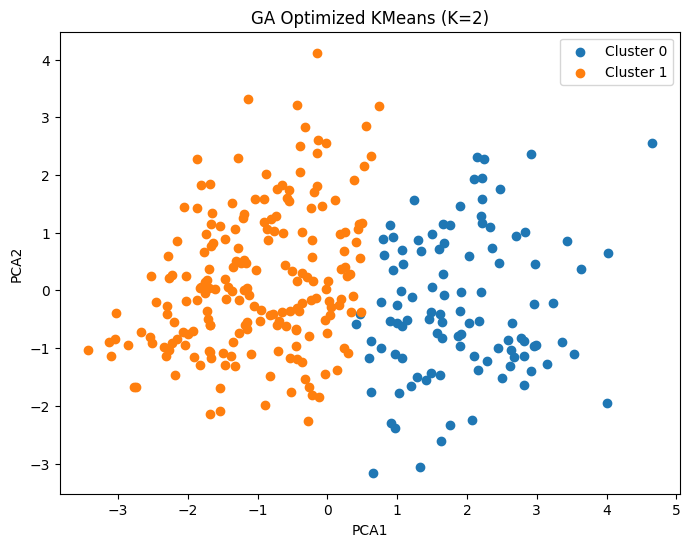


Results Saved Successfully


In [2]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

! pip install deap
from deap import base, creator, tools, algorithms

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

df = pd.read_csv("heart.csv")  

X = df.drop("target", axis=1)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

def evaluate(individual):

    k = individual[0]

    if k < 2:
        return (-1,)

    try:

        model = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=10
        )

        labels = model.fit_predict(X_scaled)

        score = silhouette_score(
            X_scaled,
            labels
        )

        return (score,)

    except:
        return (-1,)

creator.create(
    "FitnessMax",
    base.Fitness,
    weights=(1.0,)
)

creator.create(
    "Individual",
    list,
    fitness=creator.FitnessMax
)

toolbox = base.Toolbox()

toolbox.register(
    "k_value",
    random.randint,
    2,
    10
)

toolbox.register(
    "individual",
    tools.initRepeat,
    creator.Individual,
    toolbox.k_value,
    n=1
)

toolbox.register(
    "population",
    tools.initRepeat,
    list,
    toolbox.individual
)

toolbox.register(
    "evaluate",
    evaluate
)

toolbox.register(
    "mate",
    tools.cxTwoPoint
)

toolbox.register(
    "mutate",
    tools.mutUniformInt,
    low=2,
    up=10,
    indpb=1.0
)

toolbox.register(
    "select",
    tools.selTournament,
    tournsize=3
)

population = toolbox.population(
    n=20
)

algorithms.eaSimple(
    population,
    toolbox,
    cxpb=0.0, # Changed from 0.7 to 0.0 to disable crossover for single-gene individuals
    mutpb=0.2,
    ngen=15,
    verbose=True
)

best_individual = tools.selBest(
    population,
    k=1
)[0]

best_k = best_individual[0]

print("\nBest K Found:")
print(best_k)

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(
    X_scaled
)

score = silhouette_score(
    X_scaled,
    labels
)

print("\nBest Silhouette Score:")
print(score)

pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

plt.figure(figsize=(8,6))

for i in range(best_k):

    plt.scatter(
        X_pca[labels == i, 0],
        X_pca[labels == i, 1],
        label=f"Cluster {i}"
    )

plt.title(
    f"GA Optimized KMeans (K={best_k})"
)

plt.xlabel("PCA1")
plt.ylabel("PCA2")

plt.legend()

plt.show()

df["Cluster"] = labels

df.to_csv(
    "heart_ga_clusters.csv",
    index=False
)

print("\nResults Saved Successfully")